In [1]:
import pandas as pd
import re

def cut_line(lines):
    for i, line in enumerate(lines):
        if line.startswith("--------------------------------------------------\n"):
            break
    lines = lines[i+1:]
    return lines

def read_train_csv(txt_filepath: str, csv_filepath: str):
    with open(txt_filepath, 'r') as f:
        lines = f.readlines()
    
    lines = cut_line(lines)
    #lines = cut_line(lines)  # Clean start if needed
    
    epochs = []
    current_epoch = None
    
    for line in lines:
        epoch_match = re.search(r"Epoch (\d+) performance:", line)
        if epoch_match:
            if current_epoch:
                epochs.append(current_epoch)
            current_epoch = {"Epoch": int(epoch_match.group(1))}
        
        if current_epoch is not None:
            for metric in ["mAP@50:95", "mAP@50", "mAP@75", "mAR@50:95", "mAR@50", "mAR@75"]:
                metric_match = re.search(rf"metrics/test\.{metric}:(\d+\.\d+)", line)
                if metric_match:
                    current_epoch[metric] = float(metric_match.group(1))
    
    if current_epoch:
        epochs.append(current_epoch)
    
    df = pd.DataFrame(epochs)
    df.to_csv(csv_filepath, index=False)
    print(f"Saved to {csv_filepath}")
    return df

In [22]:
df = read_train_csv("train_1.txt", "train.csv")
print(df.head())

Saved to train.csv
   Epoch  mAP@50:95  mAP@50  mAP@75  mAR@50:95  mAR@50  mAR@75
0      1      0.615   0.957   0.813      0.676   1.000   0.851
1      2      0.649   0.976   0.816      0.685   0.989   0.840
2      3      0.716   0.976   0.878      0.765   1.000   0.904
3      4      0.743   0.984   0.904      0.790   1.000   0.926
4      5      0.784   0.996   0.936      0.818   1.000   0.947


<Axes: xlabel='Epoch'>

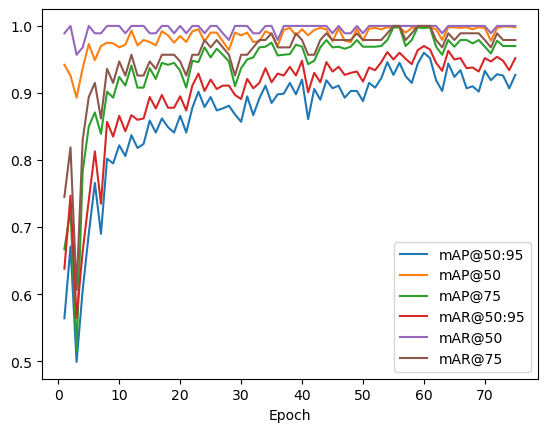

In [16]:
# Train 0
df.plot(x="Epoch", y=["mAP@50:95", "mAP@50", "mAP@75", "mAR@50:95", "mAR@50", "mAR@75"])

In [23]:
df.tail()

,Epoch,mAP@50:95,mAP@50,mAP@75,mAR@50:95,mAR@50,mAR@75
150,10,NaN,NaN,NaN,NaN,NaN,NaN
151,20,NaN,NaN,NaN,NaN,NaN,NaN
152,30,NaN,NaN,NaN,NaN,NaN,NaN
153,40,NaN,NaN,NaN,NaN,NaN,NaN
154,50,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Epoch'>

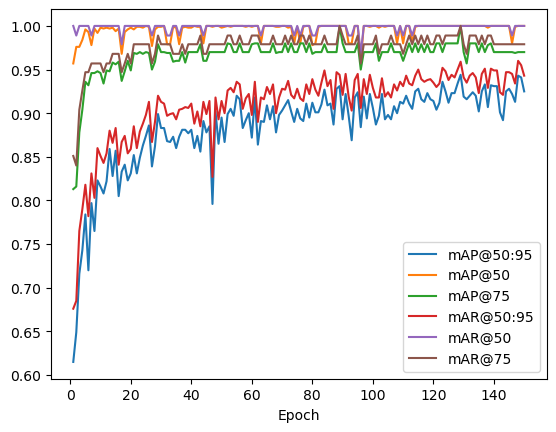

In [24]:
# Train 1
df.plot(x="Epoch", y=["mAP@50:95", "mAP@50", "mAP@75", "mAR@50:95", "mAR@50", "mAR@75"])

Saved to train_res101.csv


<Axes: xlabel='Epoch'>

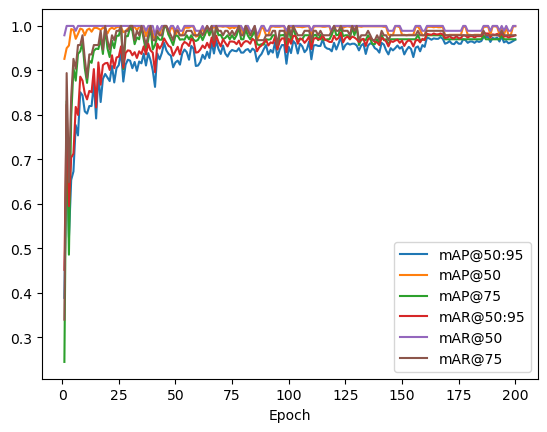

In [3]:
df_101 = read_train_csv("train_res101.txt", "train_res101.csv")
df_101.plot(x="Epoch", y=["mAP@50:95", "mAP@50", "mAP@75", "mAR@50:95", "mAR@50", "mAR@75"])

Evaluating snapshot-detector-125.pt...
[{'boxes': tensor([[466.6985, 244.0515, 863.6414, 653.3077],
        [ 50.0744, 291.9457, 584.2467, 718.6229],
        [630.7946, 300.0161, 889.4515, 632.4808]]), 'labels': tensor([1, 1, 1]), 'scores': tensor([0.9956, 0.0881, 0.0558])}]


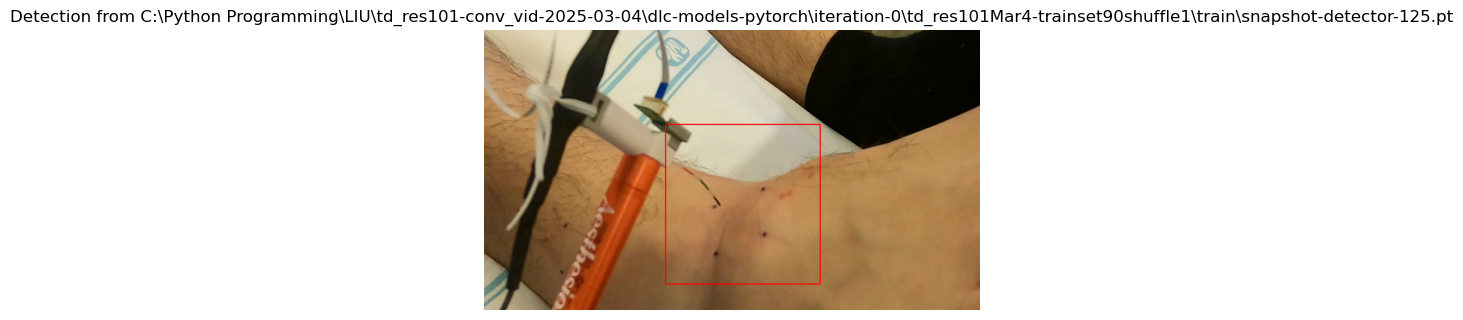

Evaluating snapshot-detector-150.pt...
[{'boxes': tensor([[478.8470, 298.5638, 822.0750, 607.5647]]), 'labels': tensor([1]), 'scores': tensor([0.9679])}]


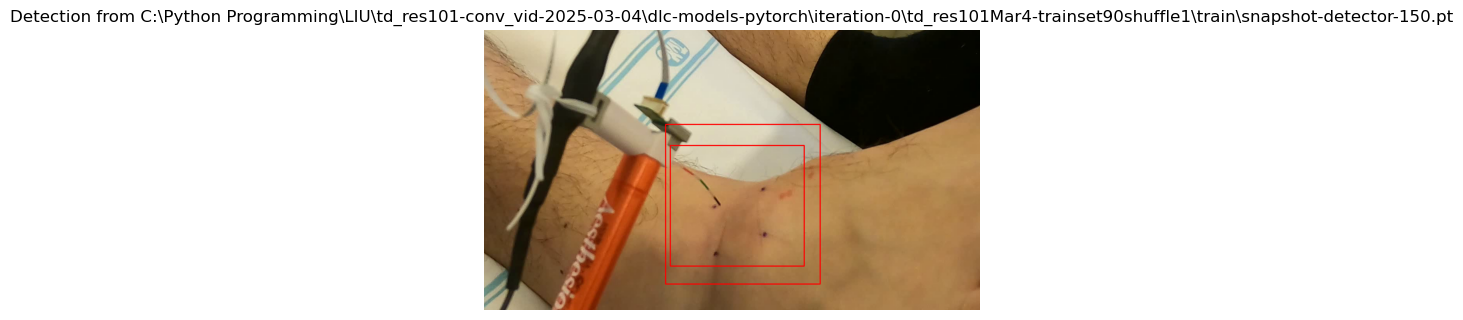

Evaluating snapshot-detector-175.pt...
[{'boxes': tensor([[ 485.9267,  297.0797,  776.0259,  613.2857],
        [ 432.6497,  246.9012,  900.6025,  683.7316],
        [ 367.2046,  341.7127, 1230.6663,  681.3294]]), 'labels': tensor([1, 1, 1]), 'scores': tensor([0.9900, 0.5513, 0.0720])}]


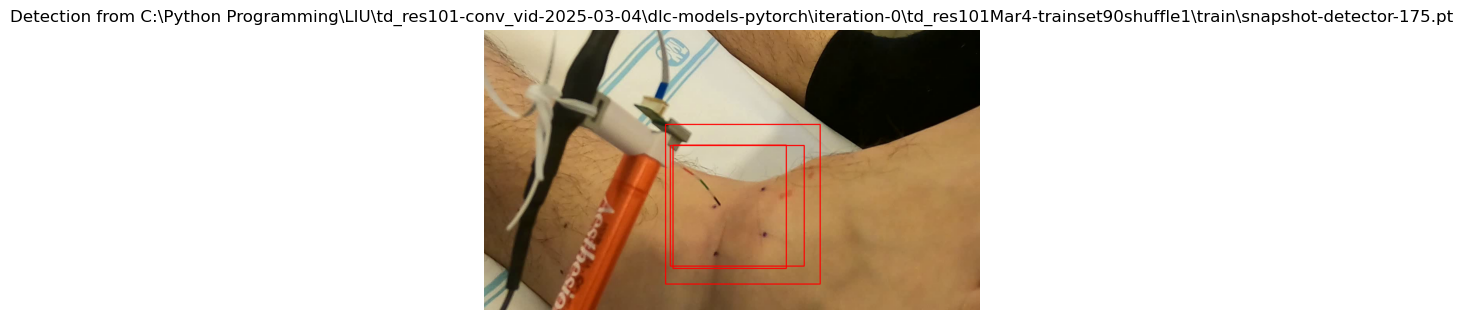

Evaluating snapshot-detector-200.pt...
[{'boxes': tensor([[ 485.1485,  297.5263,  775.0823,  624.2088],
        [ 395.7606,  282.2374, 1232.5092,  720.0000],
        [ 595.6434,  314.1026,  892.4515,  600.5931]]), 'labels': tensor([1, 1, 1]), 'scores': tensor([0.9939, 0.1368, 0.0559])}]


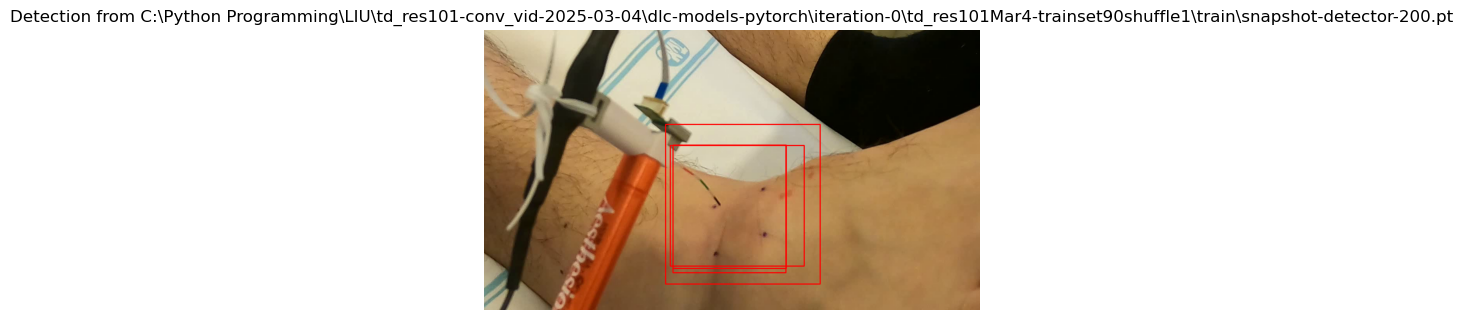

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F
import os
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2

train_path = r"C:\Python Programming\LIU\projects\td_res101-conv_vid-2025-03-04\dlc-models-pytorch\iteration-0\td_res101Mar4-trainset90shuffle1\train"  # Update this to your directory

# Get all snapshots
# ones that include "detector" in the name
snapshots = sorted([f for f in os.listdir(train_path) if f.endswith('.pt') and "detector" in f])

# Load image
image_path = r"C:\Python Programming\LIU\Data\Frame_1.png"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_tensor = F.to_tensor(image_rgb).unsqueeze(0)  # Convert to PyTorch tensor
# Normalize iamge
image_tensor = F.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

for snapshot in snapshots:
    print(f"Evaluating {snapshot}...")
    model_path = os.path.join(train_path, snapshot)

    # Define the same architecture used for training
    model = fasterrcnn_resnet50_fpn_v2(weights=None, num_classes=2)

    # Load the model
    checkpoint = torch.load(model_path, map_location=torch.device("cpu"), weights_only=False)
    new_state_dict = {key.replace("model.", ""): value for key, value in checkpoint["model"].items()}
    model.load_state_dict(new_state_dict)
    model.eval()  # Set to evaluation mode

    # Run inference
    with torch.no_grad():
        predictions = model(image_tensor)
    print(predictions)

    # Extract bounding boxes (Modify based on your model output format)
    boxes = predictions[0]["boxes"].cpu().numpy()
    scores = predictions[0]["scores"].cpu().numpy()

    # Set confidence threshold
    threshold = 0.9  # Adjust as needed
    filtered_boxes = boxes[scores > threshold]

    # Draw bounding boxes
    for box in filtered_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Show result
    plt.imshow(image_rgb)
    plt.title(f"Detection from {model_path}")
    plt.axis("off")
    plt.show()
